### What are these?

#### DevOps
##### a teamwork philosophy that unites software developers and IT workers. Instead of working in separate silos, they collaborate to build, test, and release software automatically. This eliminates bottlenecks and allows companies to push updates to users safely and continuously.
#### MLOps
##### It combines software engineering, DevOps, and data science to automate and streamline the lifecycle of ML models—from initial data preparation and model training to production deployment, monitoring, and continuous retraining
#### Kubernetes
##### automates the deployment, scaling, and management of those containers.
#### Containers
##### a lightweight package of software that includes everything needed to run an application
#### Docker
##### Docker is a platform used to containerize your software

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load local image
image_path = '/Users/sukitharathnayake/CodeRepo/ST4035/lecture notebooks/Formula 1 Dutch Grand Prix 2024.jpg'
img = Image.open(image_path)
original_size = img.size
print(f"Image loaded from: {image_path}")
print(f"Original image size (before resize): {original_size}")

# Resize for computational efficiency
img = img.resize((200, 200))
print(f"Resized image size: {img.size}")

# Convert to grayscale
img_gray = img.convert('L')

# Convert image to matrix (numpy array)
img_matrix = np.array(img_gray)
print(f"Converted grayscale image shape: {img_matrix.shape}")

# Perform SVD
U, S, Vt = np.linalg.svd(img_matrix, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"S shape: {S.shape}")
print(f"Vt shape: {Vt.shape}")
print(f"Number of components: {len(S)}")


Image loaded from: /Users/sukitharathnayake/CodeRepo/ST4035/lecture notebooks/Formula 1 Dutch Grand Prix 2024.jpg
Original image size (before resize): (1600, 900)
Resized image size: (200, 200)
Converted grayscale image shape: (200, 200)
U shape: (200, 200)
S shape: (200,)
Vt shape: (200, 200)
Number of components: 200


In [2]:
# Print image resolution before and after resizing
print(f"Resolution before resizing: {original_size[0]} x {original_size[1]}")
print(f"Resolution after resizing: {img.size[0]} x {img.size[1]}")
print(f"Final grayscale matrix shape: {img_matrix.shape[0]} x {img_matrix.shape[1]}")


Resolution before resizing: 1600 x 900
Resolution after resizing: 200 x 200
Final grayscale matrix shape: 200 x 200


Loadings shape: (200, 200)
Scores shape: (200, 200)
First 5 components loadings range: -0.2204 to 0.1682


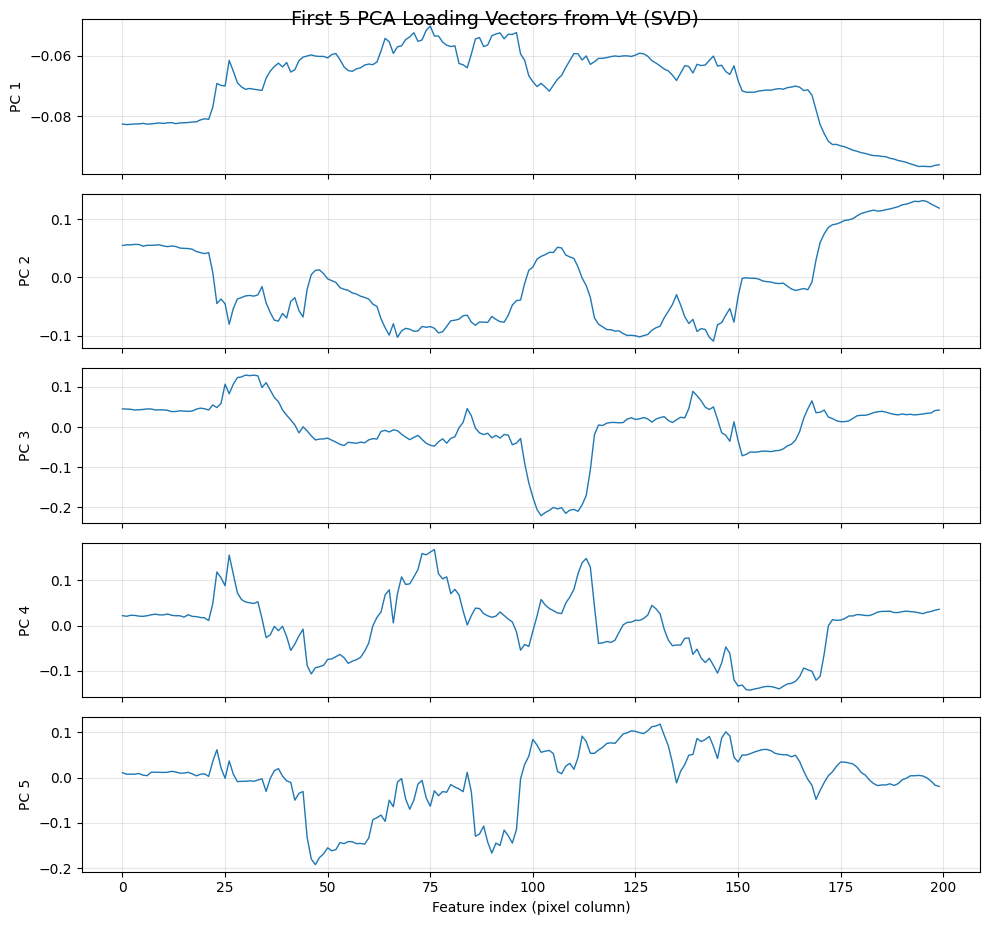

In [3]:
# Compute PCA loadings and scores from SVD
# In SVD, Vt rows represent principal component directions (loadings)
# and U*S gives the projection of the data onto those components (scores).

loadings = Vt  # shape: (components, features)
scores = U * S[np.newaxis, :]

print(f"Loadings shape: {loadings.shape}")
print(f"Scores shape: {scores.shape}")
print(f"First 5 components loadings range: {loadings[:5].min():.4f} to {loadings[:5].max():.4f}")

# Plot the first 5 PCA loading vectors
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
for i in range(5):
    axes[i].plot(loadings[i], linewidth=1)
    axes[i].set_ylabel(f"PC {i+1}")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Feature index (pixel column)')
fig.suptitle('First 5 PCA Loading Vectors from Vt (SVD)', fontsize=14, y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [4]:
# Function to reconstruct image using k principal components
def reconstruct_image(U, S, Vt, k):
    """
    Reconstruct image using first k components
    
    Formula: M_k = U[:, :k] @ diag(S[:k]) @ Vt[:k, :]
    """
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# Compute reconstruction error for each k
num_components = len(S)
reconstruction_errors = []

for k in range(1, min(50, num_components + 1)):
    reconstructed = reconstruct_image(U, S, Vt, k)
    error = np.linalg.norm(img_matrix - reconstructed, 'fro')
    reconstruction_errors.append(error)

print(f"Reconstruction errors computed for {len(reconstruction_errors)} components")


Reconstruction errors computed for 49 components


In [5]:
# Compare feature counts before and after PCA
original_pixels = img_matrix.size
original_components = len(S)

# Choose a reconstruction component count to evaluate
k = 20  # change this if you want a different number of PCA components
kept_components = k
lost_components = original_components - kept_components

percent_kept = (kept_components / original_components) * 100
percent_lost = 100 - percent_kept

print(f"Original image pixel count: {original_pixels}")
print(f"Original PCA feature count (max components): {original_components}")
print(f"Components kept: {kept_components}")
print(f"Components lost: {lost_components}")
print(f"Percent kept: {percent_kept:.2f}%")
print(f"Percent lost: {percent_lost:.2f}%")

# If you want to evaluate multiple k values:
for k_test in [5, 10, 20, 50]:
    percent_kept = (k_test / original_components) * 100
    print(f"k={k_test}: kept {percent_kept:.2f}%, lost {100-percent_kept:.2f}%")


Original image pixel count: 40000
Original PCA feature count (max components): 200
Components kept: 20
Components lost: 180
Percent kept: 10.00%
Percent lost: 90.00%
k=5: kept 2.50%, lost 97.50%
k=10: kept 5.00%, lost 95.00%
k=20: kept 10.00%, lost 90.00%
k=50: kept 25.00%, lost 75.00%


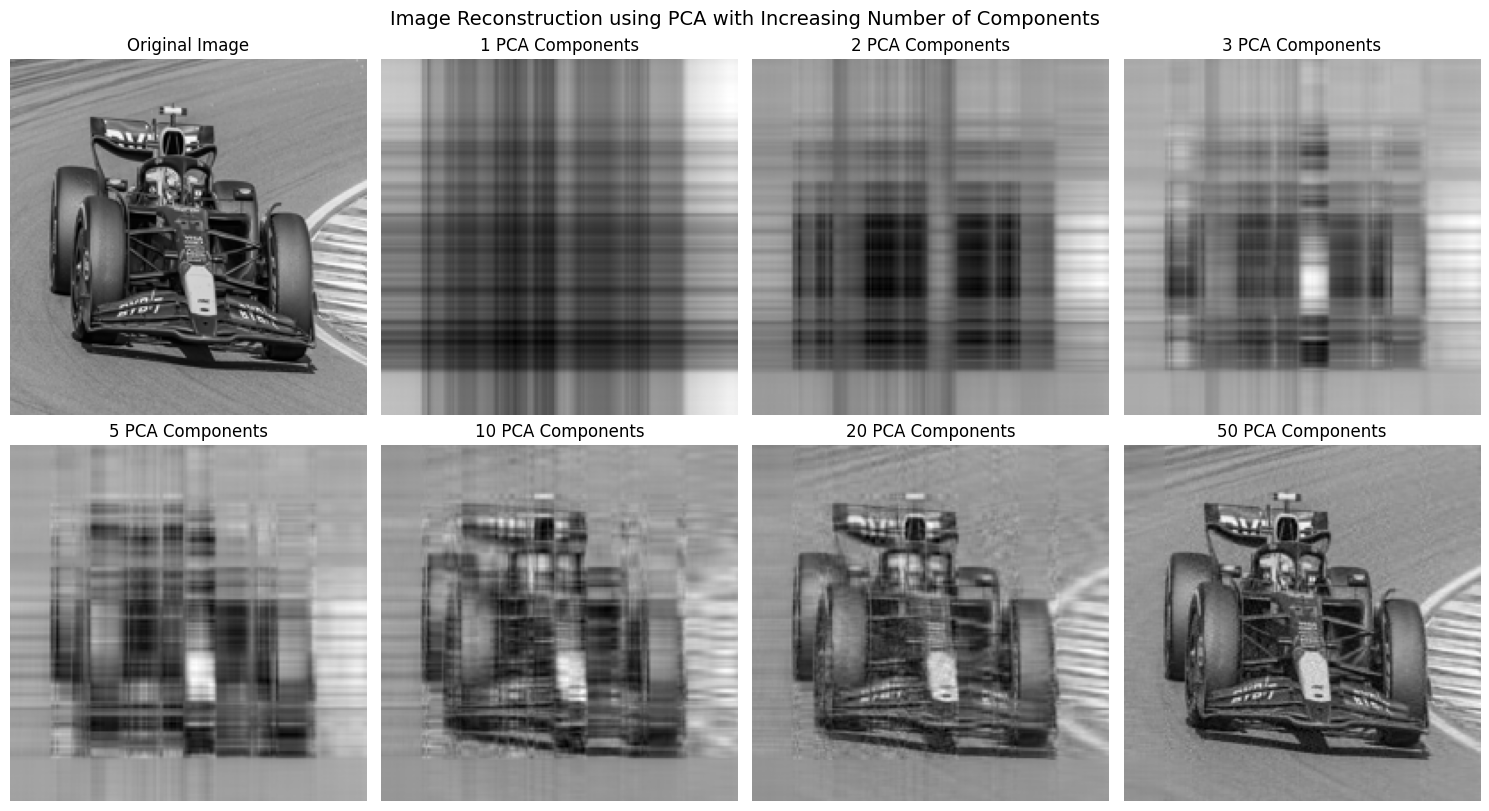

In [6]:
# Visualize progressive reconstruction with increasing components
components_to_show = [1, 2, 3, 5, 10, 20, 50]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

# Original image
axes[0].imshow(img_matrix, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Reconstructed images with different numbers of components
for idx, k in enumerate(components_to_show):
    if k <= num_components:
        reconstructed = reconstruct_image(U, S, Vt, k)
        axes[idx + 1].imshow(reconstructed, cmap='gray')
        axes[idx + 1].set_title(f'{k} PCA Components')
        axes[idx + 1].axis('off')

# Hide the last axis if not used
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Image Reconstruction using PCA with Increasing Number of Components', fontsize=14, y=1.02)
plt.show()


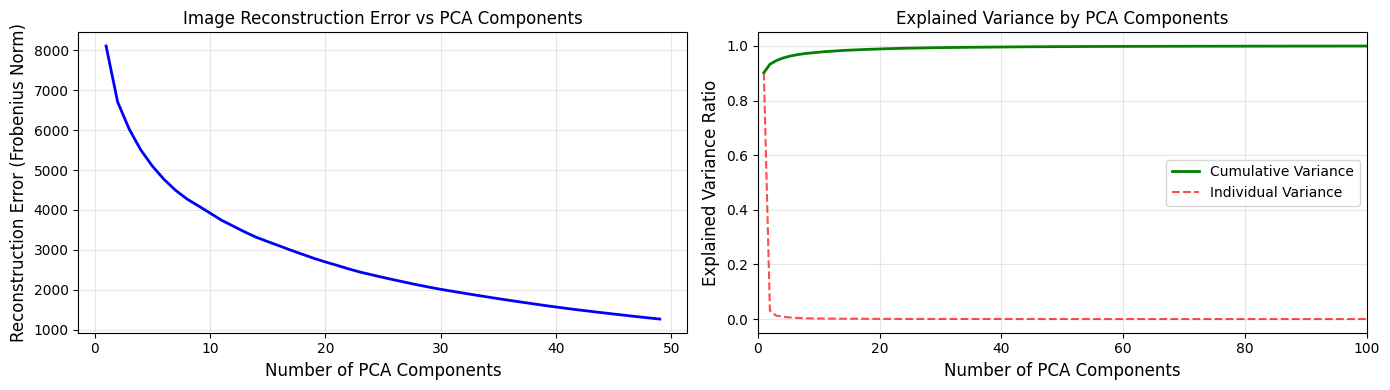


Variance explained by first 10 components: 0.9771 (97.71%)
Variance explained by first 20 components: 0.9892 (98.92%)


In [7]:
# Plot reconstruction error and explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Reconstruction Error
components_range = range(1, len(reconstruction_errors) + 1)
ax1.plot(components_range, reconstruction_errors, 'b-', linewidth=2)
ax1.set_xlabel('Number of PCA Components', fontsize=12)
ax1.set_ylabel('Reconstruction Error (Frobenius Norm)', fontsize=12)
ax1.set_title('Image Reconstruction Error vs PCA Components', fontsize=12)
ax1.grid(True, alpha=0.3)

# Explained Variance (using singular values)
explained_variance = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance)

ax2.plot(range(1, len(S) + 1), cumulative_variance, 'g-', linewidth=2, label='Cumulative Variance')
ax2.plot(range(1, len(S) + 1), explained_variance, 'r--', linewidth=1.5, alpha=0.7, label='Individual Variance')
ax2.set_xlabel('Number of PCA Components', fontsize=12)
ax2.set_ylabel('Explained Variance Ratio', fontsize=12)
ax2.set_title('Explained Variance by PCA Components', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, min(100, len(S)))

plt.tight_layout()
plt.show()

# Print variance information
print(f"\nVariance explained by first 10 components: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")
print(f"Variance explained by first 20 components: {cumulative_variance[19]:.4f} ({cumulative_variance[19]*100:.2f}%)" if len(cumulative_variance) > 19 else "Only {len(cumulative_variance)} components available")


## PCA via SVD - Mathematical Explanation

### How SVD Relates to PCA:

**Singular Value Decomposition (SVD):**
$$M = U \Sigma V^T$$

Where:
- **U**: Left singular vectors (shape: m × m)
- **Σ**: Diagonal matrix of singular values (shape: m × n)
- **V^T**: Right singular vectors transposed (shape: n × n)

**PCA Reconstruction with k components:**
$$M_k = U_{:k} \Sigma_{:k} V^T_{:k}$$

### Key Points:
1. **Singular values** represent the importance/variance captured by each component
2. **Explained Variance**: $\text{Variance}_i = \frac{\sigma_i^2}{\sum_j \sigma_j^2}$
3. **Reconstruction Error** decreases as we add more components
4. **Dimensionality Reduction**: Keep only the top k components to compress the image

### Why This Works:
- SVD identifies the principal directions of variation in the image
- Components are ordered by importance (largest singular values first)
- Adding one component at a time = Progressive refinement from coarse to fine details


## Working with Full Resolution Color Images

**Why we resized & converted to grayscale:**
1. **Resizing (200×200)**: Reduces computational cost - SVD on smaller matrices is faster
2. **Grayscale**: SVD works on 2D matrices. Color images are 3D (RGB channels) - we need to handle each channel separately

**Can we use the original image?** Yes! Here's how:


In [8]:
# Load the original image at full resolution (color)
from PIL import Image
import numpy as np

image_path = '/Users/sukitharathnayake/CodeRepo/ST4035/lecture notebooks/Formula 1 Dutch Grand Prix 2024.jpg'
img_color = Image.open(image_path)

print(f"Original image size: {img_color.size}")
print(f"Image mode: {img_color.mode}")

# Convert to numpy array (keeps RGB channels)
img_array = np.array(img_color)
print(f"Image array shape: {img_array.shape}  (height, width, channels)")

# Apply SVD to each color channel separately
U_channels = []
S_channels = []
Vt_channels = []

for channel in range(img_array.shape[2]):  # Iterate through R, G, B
    channel_matrix = img_array[:, :, channel]
    U, S, Vt = np.linalg.svd(channel_matrix, full_matrices=False)
    U_channels.append(U)
    S_channels.append(S)
    Vt_channels.append(Vt)
    print(f"Channel {channel} - Components: {len(S)}")


Original image size: (1600, 900)
Image mode: RGB
Image array shape: (900, 1600, 3)  (height, width, channels)
Channel 0 - Components: 900
Channel 1 - Components: 900
Channel 2 - Components: 900


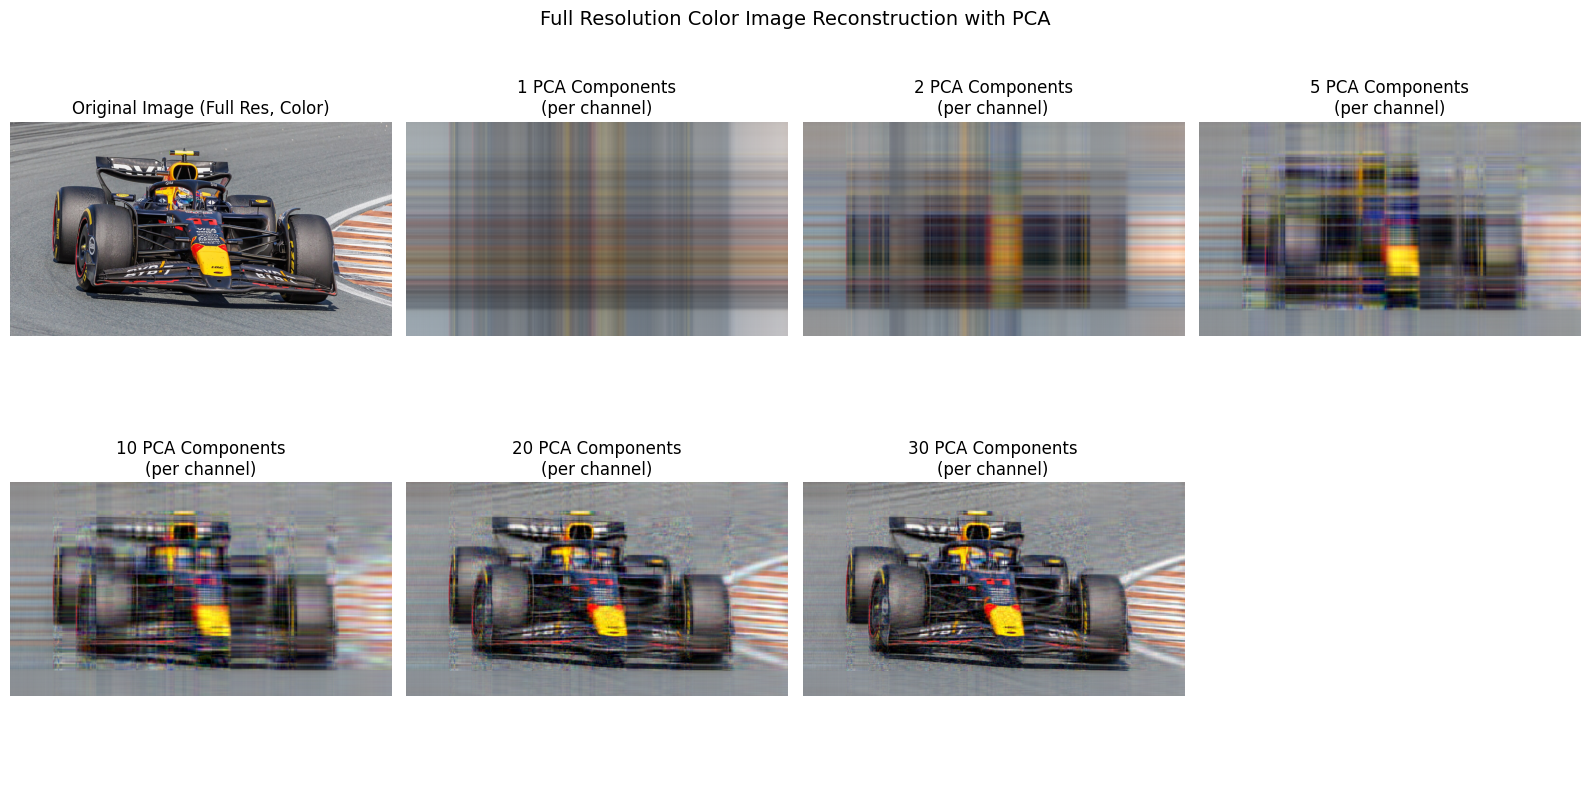


Full image size: (900, 1600, 3)
Note: Computation will take longer for large images compared to 200x200 grayscale


In [9]:
# Function to reconstruct color image with k components per channel
def reconstruct_color_image(U_channels, S_channels, Vt_channels, k):
    """
    Reconstruct color image using first k components from each RGB channel
    """
    h, w = U_channels[0].shape[0], Vt_channels[0].shape[1]
    reconstructed = np.zeros((h, w, 3), dtype=np.uint8)
    
    for channel in range(3):
        # Reconstruct each channel
        M_k = U_channels[channel][:, :k] @ np.diag(S_channels[channel][:k]) @ Vt_channels[channel][:k, :]
        # Clip values to valid range [0, 255]
        reconstructed[:, :, channel] = np.clip(M_k, 0, 255).astype(np.uint8)
    
    return reconstructed

# Visualize progressive reconstruction of color image
components_to_show = [1, 2, 5, 10, 20, 30]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Original color image
axes[0].imshow(img_color)
axes[0].set_title('Original Image (Full Res, Color)')
axes[0].axis('off')

# Reconstructed images with different numbers of components
for idx, k in enumerate(components_to_show):
    if k <= min(len(S_channels[0]), len(S_channels[1]), len(S_channels[2])):
        reconstructed_color = reconstruct_color_image(U_channels, S_channels, Vt_channels, k)
        axes[idx + 1].imshow(reconstructed_color)
        axes[idx + 1].set_title(f'{k} PCA Components\n(per channel)')
        axes[idx + 1].axis('off')

# Hide unused axis
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Full Resolution Color Image Reconstruction with PCA', fontsize=14, y=1.00)
plt.show()

print(f"\nFull image size: {img_array.shape}")
print(f"Note: Computation will take longer for large images compared to 200x200 grayscale")
